In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
pip install gluonts[torch]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 811.0/811.0 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 815.2/815.2 kB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 92.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 73.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Probabilistic Forecasting with pytorch

https://ts.gluon.ai/stable/


In [ ]:
from gluonts.dataset.pandas import PandasDataset
from gluonts.dataset.split import split
from gluonts.torch import DeepAREstimator

In [ ]:
df = pd.read_csv('daily_consumption.csv', parse_dates = True)
dff = df.loc[df['Site ID'] == 'CCC0501']
dff.info()

dff.to_csv('Processed data.csv', index = False)

<class 'pandas.core.frame.DataFrame'>
Index: 386 entries, 0 to 385
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Site ID                   386 non-null    object 
 1   Energy Consumption (kWh)  386 non-null    float64
 2   Date                      386 non-null    object 
dtypes: float64(1), object(2)
memory usage: 12.1+ KB


In [ ]:
data = pd.read_csv('Processed data.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386 entries, 0 to 385
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Site ID                   386 non-null    object 
 1   Energy Consumption (kWh)  386 non-null    float64
 2   Date                      386 non-null    object 
dtypes: float64(1), object(2)
memory usage: 9.2+ KB


In [ ]:
data['Date'] = pd.to_datetime(data['Date'], format = "mixed")
data = data.set_index(data['Date'])
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 386 entries, 2019-11-01 to 2020-11-20
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Site ID                   386 non-null    object        
 1   Energy Consumption (kWh)  386 non-null    float64       
 2   Date                      386 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 12.1+ KB


In [ ]:
dataset = PandasDataset(data, target = 'Energy Consumption (kWh)')

# Split the data into train and test
training_data, test_data = split(dataset, offset = -36)
test = test_data.generate_instances(prediction_length = 35) #windows = 3

In [ ]:
%%time

model = DeepAREstimator(
    prediction_length = 35, freq = "D", trainer_kwargs = {"max_epochs": 5}).train(training_data)

forecasts = list(model.predict(test.input))

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
/usr/local/lib/python3.11/dist-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
INFO: 
  | Name  | Type        | Params | Mode  | In sizes                                                         | Out sizes   
--------------------------------------------------------------------------------------------------------------------------------
0 | model | DeepARModel | 25.9 K | train | [[1, 1], [1, 1], [1, 1127, 4], [1, 1127], [1, 1127], [1, 35, 4]] | [1, 100, 35]
-----------------------------------------------------------------------

Training: |          | 0/? [00:00<?, ?it/s]

INFO: Epoch 0, global step 50: 'train_loss' reached 7.84508 (best 7.84508), saving model to '/content/lightning_logs/version_0/checkpoints/epoch=0-step=50.ckpt' as top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 0, global step 50: 'train_loss' reached 7.84508 (best 7.84508), saving model to '/content/lightning_logs/version_0/checkpoints/epoch=0-step=50.ckpt' as top 1
INFO: Epoch 1, global step 100: 'train_loss' reached 7.42289 (best 7.42289), saving model to '/content/lightning_logs/version_0/checkpoints/epoch=1-step=100.ckpt' as top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 1, global step 100: 'train_loss' reached 7.42289 (best 7.42289), saving model to '/content/lightning_logs/version_0/checkpoints/epoch=1-step=100.ckpt' as top 1
INFO: Epoch 2, global step 150: 'train_loss' reached 7.12321 (best 7.12321), saving model to '/content/lightning_logs/version_0/checkpoints/epoch=2-step=150.ckpt' as top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 2, global step 150: '

CPU times: user 25.3 s, sys: 2.14 s, total: 27.4 s
Wall time: 33.1 s


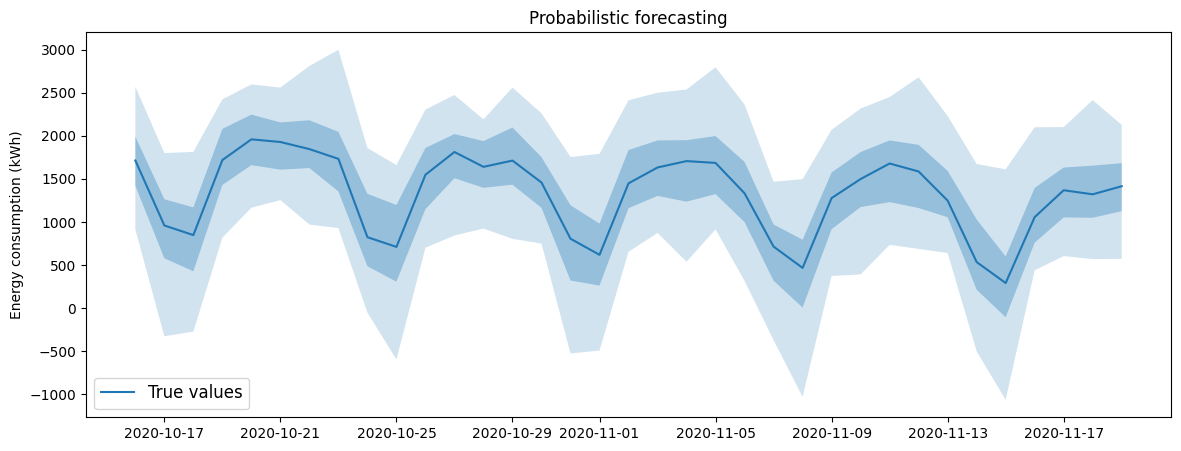

In [ ]:
#plt.plot(data.Date["2020-10-20":], color = "black")
plt.figure(figsize = (14,5))
for forecast in forecasts:
    forecast.plot()
plt.title('Probabilistic forecasting')
plt.ylabel ('Energy consumption (kWh)')
plt.legend(["True values"], loc = "lower left", fontsize = "large")
plt.show()

**The forecasts are displayed in terms of a probability distribution and the shaded areas represent the 50% and 90% prediction intervals.**